# MIL Survival Model Training

Training a Multiple Instance Learning model with gated attention and DeepHit loss.

In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import torchtuples as tt

from utils import MILSurvivalModel, create_feature_dataloaders
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models.data import pair_rank_mat
from pycox.models import loss as pycox_loss
from pycox.evaluation import EvalSurv

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda:1' if torch.cuda.is_available() else 'cpu'
CHECKPOINT_DIR = Path('./checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda:1


## Configuration

In [2]:
CONFIG = {
    # Training
    'batch_size': 32,
    'epochs': 200,
    'learning_rate': 5e-5,
    'weight_decay': 5e-3,
    
    # Model Architecture
    'num_duration_bins': 16,
    'feature_dim': 1536,
    'hidden_dim': 128,
    'attention_dim': 64,
    'num_patches': 150,
    'dropout': 0.6,
    
    # DeepHit Loss
    'alpha': 0.4,
    'sigma': 0.2,
    
    # Early Stopping
    'early_stopping_patience': 15
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  batch_size: 32
  epochs: 200
  learning_rate: 5e-05
  weight_decay: 0.005
  num_duration_bins: 16
  feature_dim: 1536
  hidden_dim: 128
  attention_dim: 64
  num_patches: 150
  dropout: 0.6
  alpha: 0.4
  sigma: 0.2
  early_stopping_patience: 15


## Load Data

In [3]:
df = pd.read_csv('./data/clinical_data_split.csv')
tabular_cols = [c for c in df.columns if c not in ['patient_id', 'time', 'event', 'split']]

print(f"Tabular features ({len(tabular_cols)}): {tabular_cols}")
print(f"\nDataset splits:")
for split in ['train', 'val', 'test']:
    subset = df[df['split'] == split]
    print(f"  {split}: {len(subset)} patients, {subset['event'].sum():.0f} events ({subset['event'].mean()*100:.1f}%)")

Tabular features (21): ['age', 'LN_examined', 'M_M1', 'M_MX', 'N_N1', 'N_N2', 'N_N3', 'N_NX', 'T_T1', 'T_T3', 'T_T4', 'T_TX', 'menopause_indeterminate', 'menopause_pre', 'stage_I', 'stage_III', 'stage_IV', 'stage_X', 'surgery_lumpectomy', 'surgery_other', 'surgery_simple_mastectomy']

Dataset splits:
  train: 693 patients, 99 events (14.3%)
  val: 149 patients, 21 events (14.1%)
  test: 148 patients, 21 events (14.2%)


## Fit Label Transformer

In [4]:
labtrans = LabTransDiscreteTime(CONFIG['num_duration_bins'], scheme='quantiles')
labtrans.fit(df['time'].values, df['event'].values)

TIME_BINS = labtrans.cuts.tolist()
print(f"Time bins ({len(TIME_BINS)}): {np.round(TIME_BINS, 2)}")

# Transform labels
df_transformed = df.copy()[['patient_id', 'time', 'event', 'split'] + tabular_cols]
y = labtrans.transform(df_transformed['time'].values, df_transformed['event'].values)
df_transformed['idx_duration'] = y[0]
df_transformed['event_transformed'] = y[1]
df_transformed.to_csv('./data/clinical_data_transformed.csv', index=False)

Time bins (16): [ 0.    1.98  2.87  4.24  5.17  6.43  7.42  8.08  9.21 10.02 10.75 11.59
 17.23 17.68 19.51 23.56]


## Create DataLoaders

In [5]:
train_loader, val_loader, test_loader = create_feature_dataloaders(
    clinical_csv='./data/clinical_data_transformed.csv',
    feature_dir='./data/extracted_features',
    batch_size=CONFIG['batch_size'],
    num_workers=0,
    max_patches=CONFIG['num_patches']
)

TRAIN: 693 patients with features
VAL: 149 patients with features
TEST: 148 patients with features


## Create Model

In [6]:
net = MILSurvivalModel(
    feature_dim=CONFIG['feature_dim'],
    num_durations=CONFIG['num_duration_bins'],
    tabular_dim=len(tabular_cols),
    hidden_dim=CONFIG['hidden_dim'],
    attention_dim=CONFIG['attention_dim'],
    dropout=CONFIG['dropout']
)

optimizer = torch.optim.AdamW(
    net.parameters(), 
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

def mil_deephit_loss(scores, idx_durations, events):
    """DeepHit loss with ranking matrix."""
    rank_mat = pair_rank_mat(idx_durations.cpu().numpy(), events.cpu().numpy())
    rank_mat = torch.from_numpy(rank_mat).to(scores.device)
    loss_fn = pycox_loss.DeepHitSingleLoss(CONFIG['alpha'], CONFIG['sigma'])
    return loss_fn(scores, idx_durations, events, rank_mat)

model = DeepHitSingle(
    net, optimizer,
    alpha=CONFIG['alpha'],
    sigma=CONFIG['sigma'],
    duration_index=TIME_BINS,
    loss=mil_deephit_loss,
    device=DEVICE
)

print(f"Model parameters: {sum(p.numel() for p in net.parameters()):,}")

Model parameters: 438,331


## Train Model

In [7]:
callbacks = [
    tt.callbacks.EarlyStopping(
        patience=CONFIG['early_stopping_patience'],
        file_path=f'{CHECKPOINT_DIR}/ckpt_model.pt'
    )
]

log = model.fit_dataloader(
    train_loader,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
    val_dataloader=val_loader
)

# Save final model
torch.save(model.net.state_dict(), f'{CHECKPOINT_DIR}/final_model.pt')
print(f"\nBest validation loss: {min([l for l in log.to_pandas()['val_loss'] if not np.isnan(l)]):.4f}")

0:	[1s / 1s],		train_loss: 0.2676,	val_loss: 0.2589
1:	[1s / 2s],		train_loss: 0.2648,	val_loss: 0.2584
2:	[1s / 4s],		train_loss: 0.2644,	val_loss: 0.2580
3:	[1s / 5s],		train_loss: 0.2633,	val_loss: 0.2575
4:	[1s / 6s],		train_loss: 0.2632,	val_loss: 0.2570
5:	[1s / 7s],		train_loss: 0.2638,	val_loss: 0.2564
6:	[1s / 8s],		train_loss: 0.2657,	val_loss: 0.2557
7:	[1s / 10s],		train_loss: 0.2611,	val_loss: 0.2547
8:	[1s / 11s],		train_loss: 0.2601,	val_loss: 0.2534
9:	[1s / 12s],		train_loss: 0.2601,	val_loss: 0.2515
10:	[1s / 13s],		train_loss: 0.2540,	val_loss: 0.2490
11:	[1s / 14s],		train_loss: 0.2560,	val_loss: 0.2468
12:	[1s / 15s],		train_loss: 0.2497,	val_loss: 0.2447
13:	[1s / 16s],		train_loss: 0.2515,	val_loss: 0.2432
14:	[1s / 17s],		train_loss: 0.2494,	val_loss: 0.2421
15:	[1s / 18s],		train_loss: 0.2529,	val_loss: 0.2410
16:	[1s / 19s],		train_loss: 0.2489,	val_loss: 0.2403
17:	[1s / 20s],		train_loss: 0.2502,	val_loss: 0.2396
18:	[1s / 21s],		train_loss: 0.2444,	val_loss

## Evaluation

In [ ]:
# Fix scipy compatibility
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

model.net.eval()
time_grid = np.linspace(0, df['time'].max(), 100)

# Number of repetitions (due to the randomness in patch sampling)
n_repeats = 50

for split_name, loader in [('Val', val_loader), ('Test', test_loader)]:
    res_c = 0
    res_ibs = 0
    for _ in range(n_repeats):
        inputs, target = next(iter(loader))
        surv = model.predict_surv_df(input=inputs)
        ev = EvalSurv(surv, target[0].numpy(), target[1].numpy(), censor_surv='km')
        res_c += ev.concordance_td()
        res_ibs += ev.integrated_brier_score(time_grid)
    res_c /= n_repeats
    res_ibs /= n_repeats
    print(f"{split_name}: C-index = {res_c:.4f}, IBS = {res_ibs:.4f}")

Val: C-index = 0.6725, IBS = 0.1320
Test: C-index = 0.7383, IBS = 0.1515


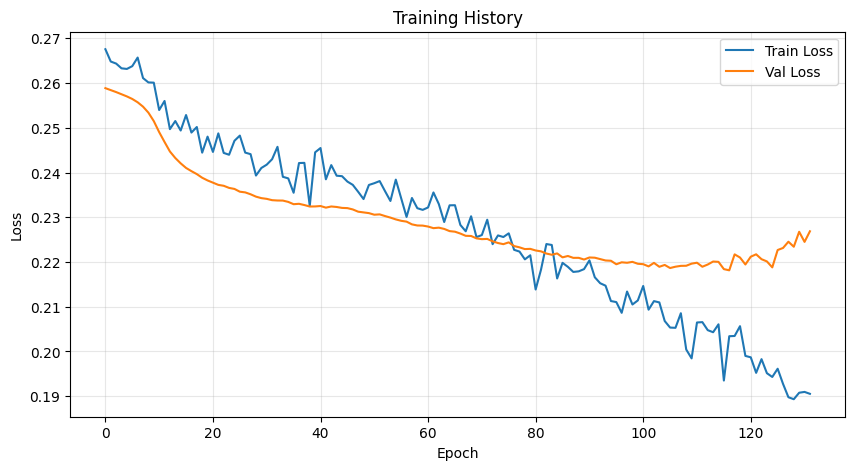

In [9]:
# Plot training history
log_df = log.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(log_df['train_loss'], label='Train Loss')
plt.plot(log_df['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{CHECKPOINT_DIR}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()